Data Exploration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')


Data Preparation

In [2]:
df_dataset = pd.read_csv('/workspaces/ML-Zoomcamp-Homework/Disease-Symptoms-Classifier/Diseases-Symptoms Dataset/dataset.csv')
df_symptom_severity = pd.read_csv('/workspaces/ML-Zoomcamp-Homework/Disease-Symptoms-Classifier/Diseases-Symptoms Dataset/Symptom-severity.csv')
df_symptom_description = pd.read_csv('/workspaces/ML-Zoomcamp-Homework/Disease-Symptoms-Classifier/Diseases-Symptoms Dataset/symptom_Description.csv')
df_symptom_precaution = pd.read_csv('/workspaces/ML-Zoomcamp-Homework/Disease-Symptoms-Classifier/Diseases-Symptoms Dataset/symptom_precaution.csv')

In [3]:
print("Dataset Info:")
print(df_dataset.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB
None


In [4]:
df_dataset.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_dataset.shape

(4920, 18)

In [6]:
df_dataset.columns

Index(['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
       'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9',
       'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14',
       'Symptom_15', 'Symptom_16', 'Symptom_17'],
      dtype='object')

In [7]:
df_dataset.dtypes

Disease       object
Symptom_1     object
Symptom_2     object
Symptom_3     object
Symptom_4     object
Symptom_5     object
Symptom_6     object
Symptom_7     object
Symptom_8     object
Symptom_9     object
Symptom_10    object
Symptom_11    object
Symptom_12    object
Symptom_13    object
Symptom_14    object
Symptom_15    object
Symptom_16    object
Symptom_17    object
dtype: object

In [8]:
print("\nSymptom Severity Info:")
print(df_symptom_severity.info())


Symptom Severity Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Symptom  133 non-null    object
 1   weight   133 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [9]:
print("\nMissing Values in Dataset")
print(df_dataset.isnull().sum())


Missing Values in Dataset
Disease          0
Symptom_1        0
Symptom_2        0
Symptom_3        0
Symptom_4      348
Symptom_5     1206
Symptom_6     1986
Symptom_7     2652
Symptom_8     2976
Symptom_9     3228
Symptom_10    3408
Symptom_11    3726
Symptom_12    4176
Symptom_13    4416
Symptom_14    4614
Symptom_15    4680
Symptom_16    4728
Symptom_17    4848
dtype: int64


In [10]:
print(f"\nUnique Diseases: {df_dataset['Disease'].nunique()}")


Unique Diseases: 41


In [11]:
symptom_columns = [col for col in df_dataset.columns if col.startswith('Symptom_')]
print(f"\nNumber of symptom columns: {len(symptom_columns)}")


Number of symptom columns: 17


In [12]:
symptom_counts = df_dataset[symptom_columns].count(axis=1)
print(f"\nAverage symptoms per disease: {symptom_counts.mean():.2f}")


Average symptoms per disease: 7.45


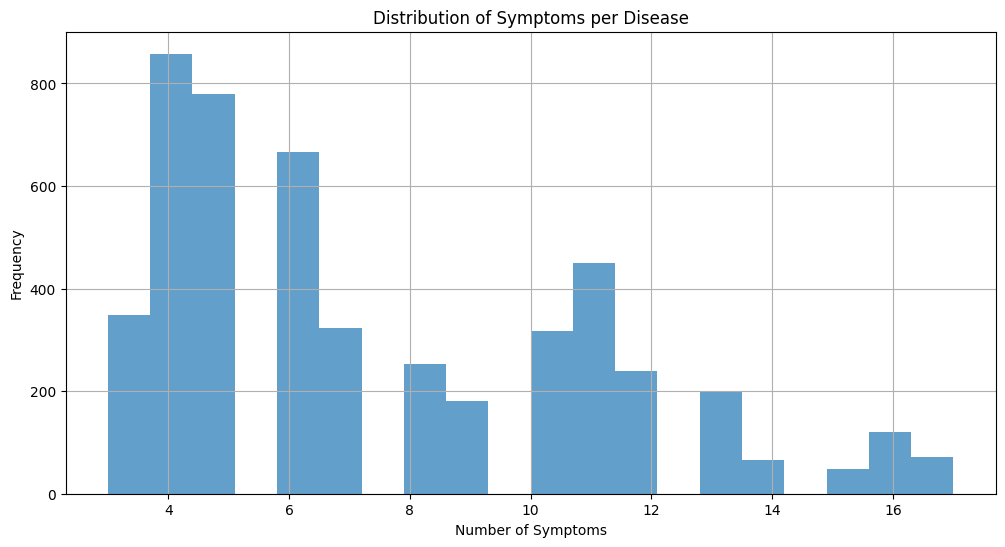

In [13]:
plt.figure(figsize=(12, 6))
symptom_counts.hist(bins=20, alpha=0.7)
plt.title('Distribution of Symptoms per Disease')
plt.xlabel('Number of Symptoms')
plt.ylabel('Frequency')
plt.show()

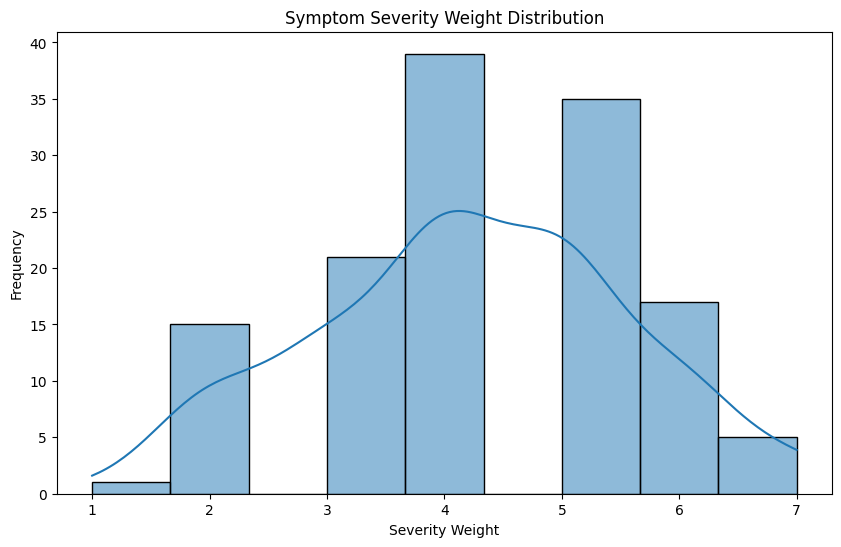

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df_symptom_severity['weight'], kde=True)
plt.title('Symptom Severity Weight Distribution')
plt.xlabel('Severity Weight')
plt.ylabel('Frequency')
plt.show()

In [15]:
most_severe = df_symptom_severity.nlargest(10, 'weight')
print("\nTop 10 Most Severe Symptoms:")
print(most_severe)


Top 10 Most Severe Symptoms:
                 Symptom  weight
25            high_fever       7
46   swelling_of_stomach       7
56            chest_pain       7
57     weakness_in_limbs       7
113                 coma       7
12   burning_micturition       6
13    spotting_urination       6
22     patches_in_throat       6
40             diarrhoea       6
44   acute_liver_failure       6


Disease Distribution

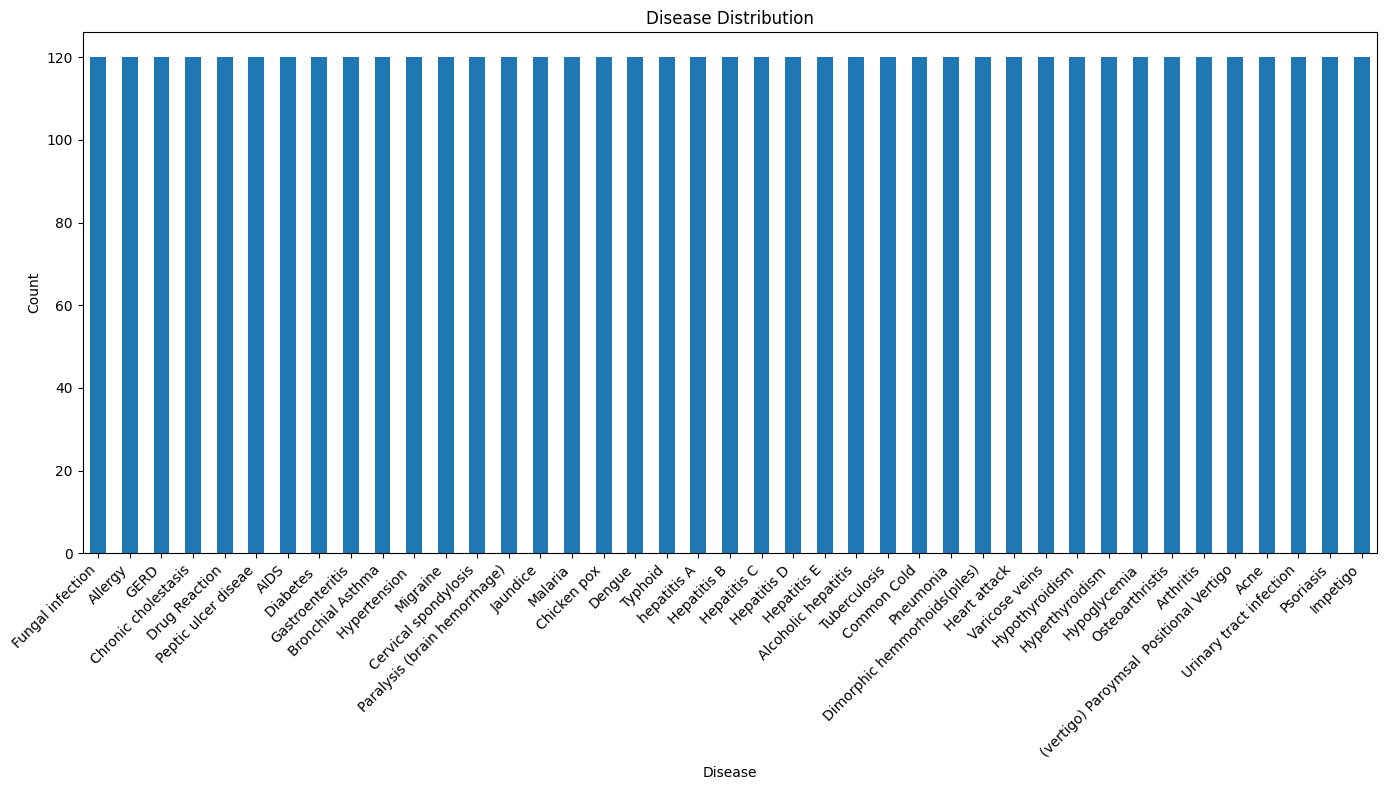

In [16]:
plt.figure(figsize=(14, 8))
disease_counts = df_dataset['Disease'].value_counts()
disease_counts.plot(kind='bar')
plt.title('Disease Distribution')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Common Symptoms

In [17]:
symptom_presence = df_dataset[symptom_columns].notnull().sum().sort_values(ascending=False)
print("\nTop Most Common Symptoms:")
print(symptom_presence.head(10))


Top Most Common Symptoms:
Symptom_1     4920
Symptom_2     4920
Symptom_3     4920
Symptom_4     4572
Symptom_5     3714
Symptom_6     2934
Symptom_7     2268
Symptom_8     1944
Symptom_9     1692
Symptom_10    1512
dtype: int64


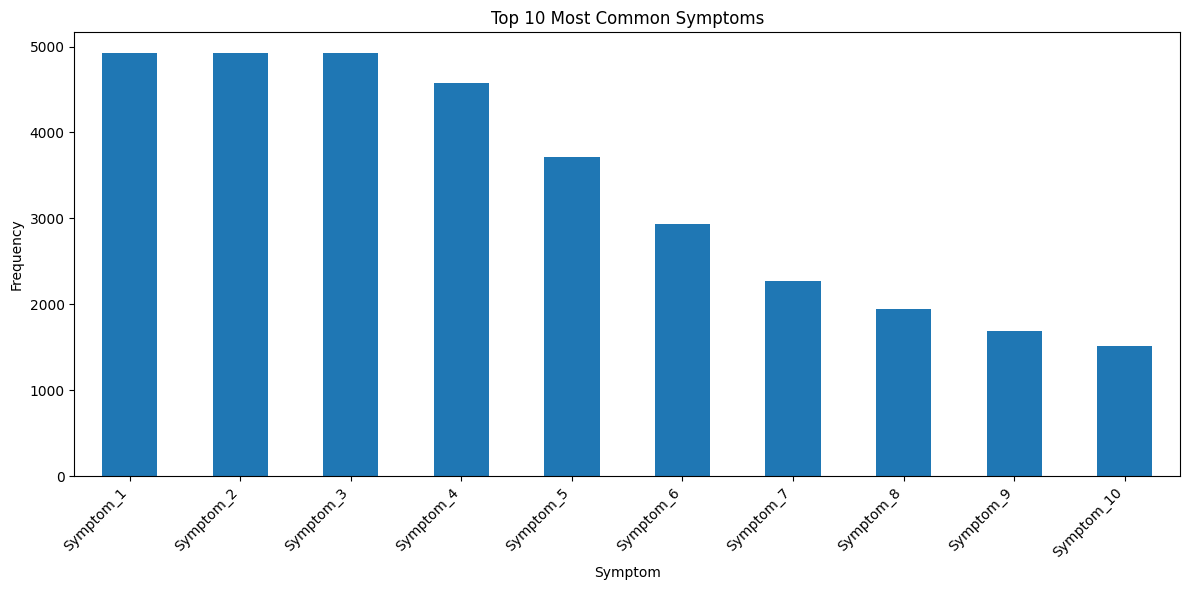

In [18]:
plt.figure(figsize=(12, 6))
symptom_presence.head(10).plot(kind='bar')
plt.title('Top 10 Most Common Symptoms')
plt.xlabel('Symptom')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Correlation Analysis

In [19]:
symptom_binary = df_dataset[symptom_columns].notnull().astype(int)
correlation_matrix = symptom_binary.corr()

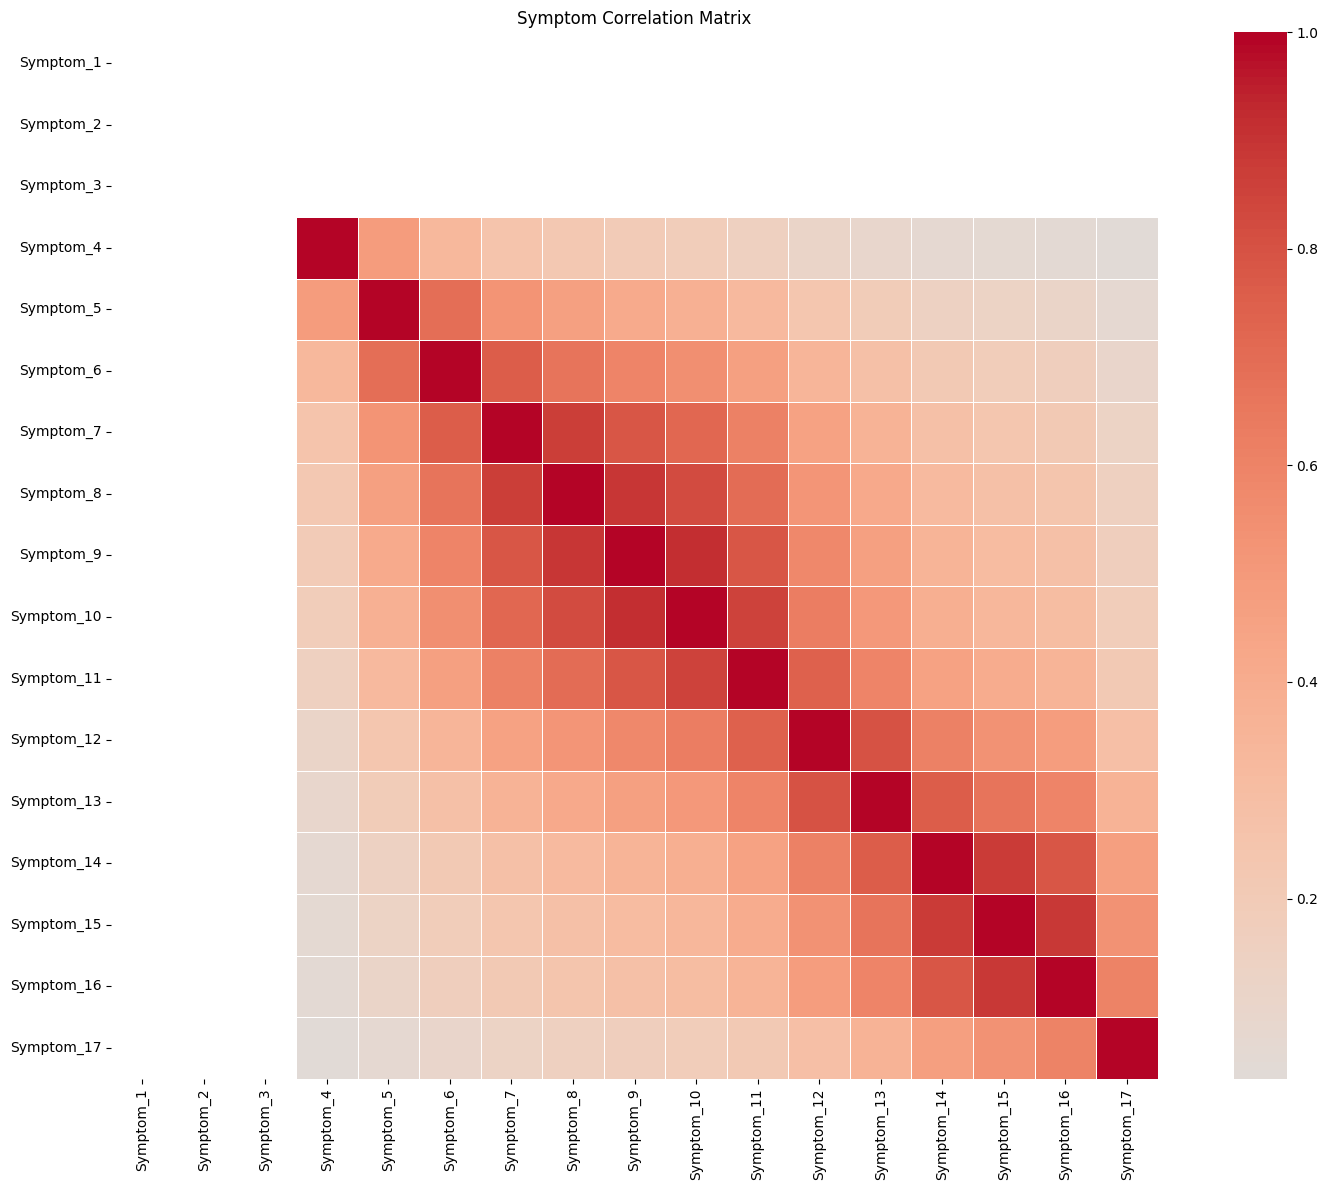

In [20]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Symptom Correlation Matrix')
plt.tight_layout()
plt.show()

# 